Starting Day 1 on 5/25/2026 

In [40]:
import matplotlib.pyplot as plt

In [5]:
words = open('names.txt', 'r').read().splitlines()


In [7]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [9]:
print(min(len(w) for w in words))
print(max(len(w) for w in words))

2
15


First we build the Bigram language model. We will be working with a list of names, and we want to learn how to generate new names that look similar to the ones in the list.

In [17]:
b = {}
for w in words[:]:
    chs = ['<S'] + list(w) + ['<E']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
# To figure out how common the characters are next to each other, we are going to count!

In [22]:
# sorted(b.items(), key= lambda kv: -kv[1]) 
# It's going to be convenient for us to use a 2D array instead of a dict

In [30]:
import torch
a = torch.zeros((3, 5), dtype= torch.int32) # since we will only use counts, int is better
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [33]:
# we require a bigger array, that contains all alphabets + two new characters (<S and <E)
N = torch.zeros((28, 28), dtype = torch.int32)

We need a way to convert the characters to numbers

In [37]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)} # enumerate gives index and the element in that index
stoi['<S'] = 26
stoi['<E'] = 27

In [41]:
for w in words[:]:
    chs = ['<S'] + list(w) + ['<E']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [53]:
N[3, 3].item() # gives the direct integer instead of a tensor

149

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

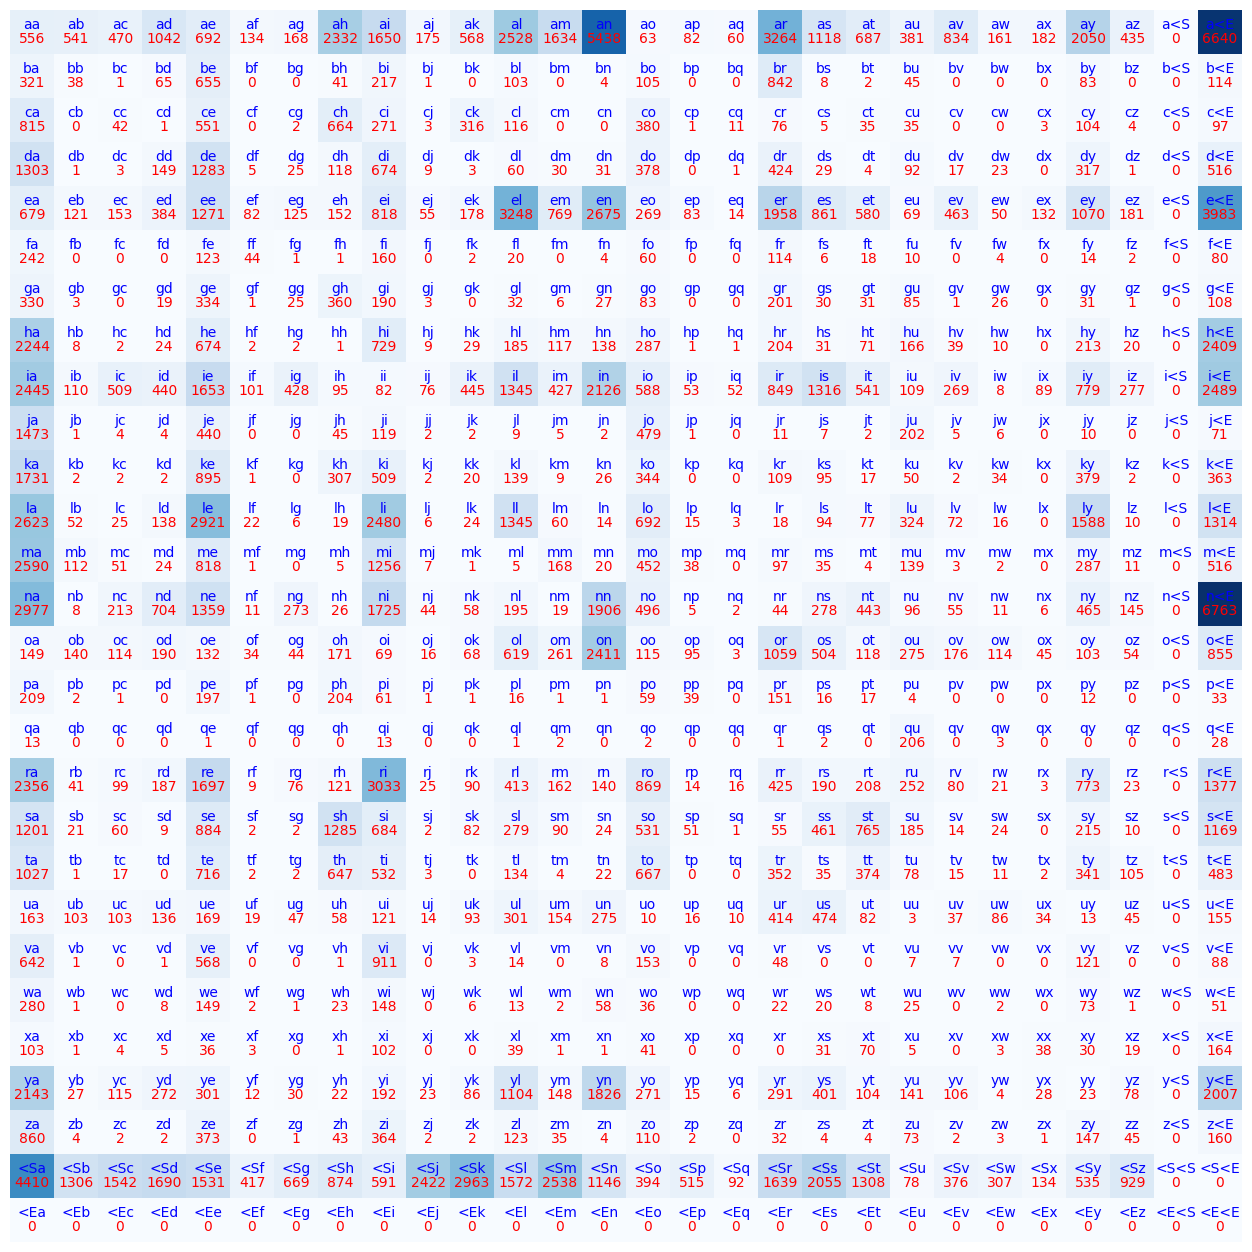

In [50]:
itos = {i:s for s, i in stoi.items()}
plt.figure(figsize= (16, 16))
plt.imshow(N, cmap= 'Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color= 'blue')
        plt.text(j, i, N[i,j].item(), ha='center', va='top', color= 'red') 
plt.axis('off')